## Question 2: Classification & Logistic Regression – Employee Attrition or Credit Risk

### Scenario

You are hired by an organization to build a system that predicts a **binary outcome**:

* Whether an **employee will leave** the company, OR
* Whether a **customer will default** on a credit card payment.

### Datasets (Choose ONE)

* **IBM HR Analytics Employee Attrition Dataset**
  [https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset](https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset)

* **Credit Card Default Dataset**
  [https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset](https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset)

### Tasks

1. Justify why **Logistic Regression** is suitable for this problem.
2. Perform full **data preprocessing**:

   * Missing value handling
   * Encoding categorical variables
   * Feature scaling
3. Train a **Logistic Regression** classifier.
4. Evaluate the model using:

   * Confusion Matrix
   * Precision, Recall, F1-score
   * AUC Score
5. Interpret model coefficients using **odds ratios**.
6. Discuss the impact of **class imbalance** and possible solutions.

___
___

About Dataset
Uncover the factors that lead to employee attrition and explore important questions such as ‘show me a breakdown of distance from home by job role and attrition’ or ‘compare average monthly income by education and attrition’. This is a fictional data set created by IBM data scientists.

Education
1 'Below College'
2 'College'
3 'Bachelor'
4 'Master'
5 'Doctor'

EnvironmentSatisfaction
1 'Low'
2 'Medium'
3 'High'
4 'Very High'

JobInvolvement
1 'Low'
2 'Medium'
3 'High'
4 'Very High'

JobSatisfaction
1 'Low'
2 'Medium'
3 'High'
4 'Very High'

PerformanceRating
1 'Low'
2 'Good'
3 'Excellent'
4 'Outstanding'

RelationshipSatisfaction
1 'Low'
2 'Medium'
3 'High'
4 'Very High'

WorkLifeBalance
1 'Bad'
2 'Good'
3 'Better'
4 'Best'

___
___

## Data understanding

In [91]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [92]:
df = pd.read_csv("Employee.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [93]:
df.shape

(1470, 35)

The dataset has 35 columns and 1470 rows of data.

In [94]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

The dataset contains 26 integer data column and 9 string data column.
It was observed that there are no null data in any column of the dataset.

In [95]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


 ### Key observations

 - **Age:** Average age is **36.92**, ranging from **18 to 60**.
- **DailyRate:** Mean = **802.49**, with values from **102 to 1,499**.
- **MonthlyIncome:** Mean = **6,502.93**, ranging from **1,009 to 19,999**.
- **DistanceFromHome:** Average distance is **9.19**, with a median of **7**.
- **JobLevel:** Mean = **2.06**, ranging from **1 to 5**.
- **TotalWorkingYears:** Average experience is **11.28 years**, maximum **40 years**.
- **YearsAtCompany:** Average tenure is **7.01 years**, maximum **40 years**.
- **JobSatisfaction:** Mean = **2.73** on a 1–4 scale.
- **PerformanceRating:** Mean = **3.15**, with only values **3 and 4**.

___
- **EmployeeCount** and **StandardHours** have **zero standard deviation**, meaning they are constant and can generally be removed from analysis.
- **EmployeeNumber** is an identifier rather than a meaningful analytical variable, so it would typically also be excluded from modeling.

___
___

## Visualization

In [96]:
df.select_dtypes(include="number").columns

Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='str')

___
- Employee count, Employee number and standard hours were not taken for visualization.

['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


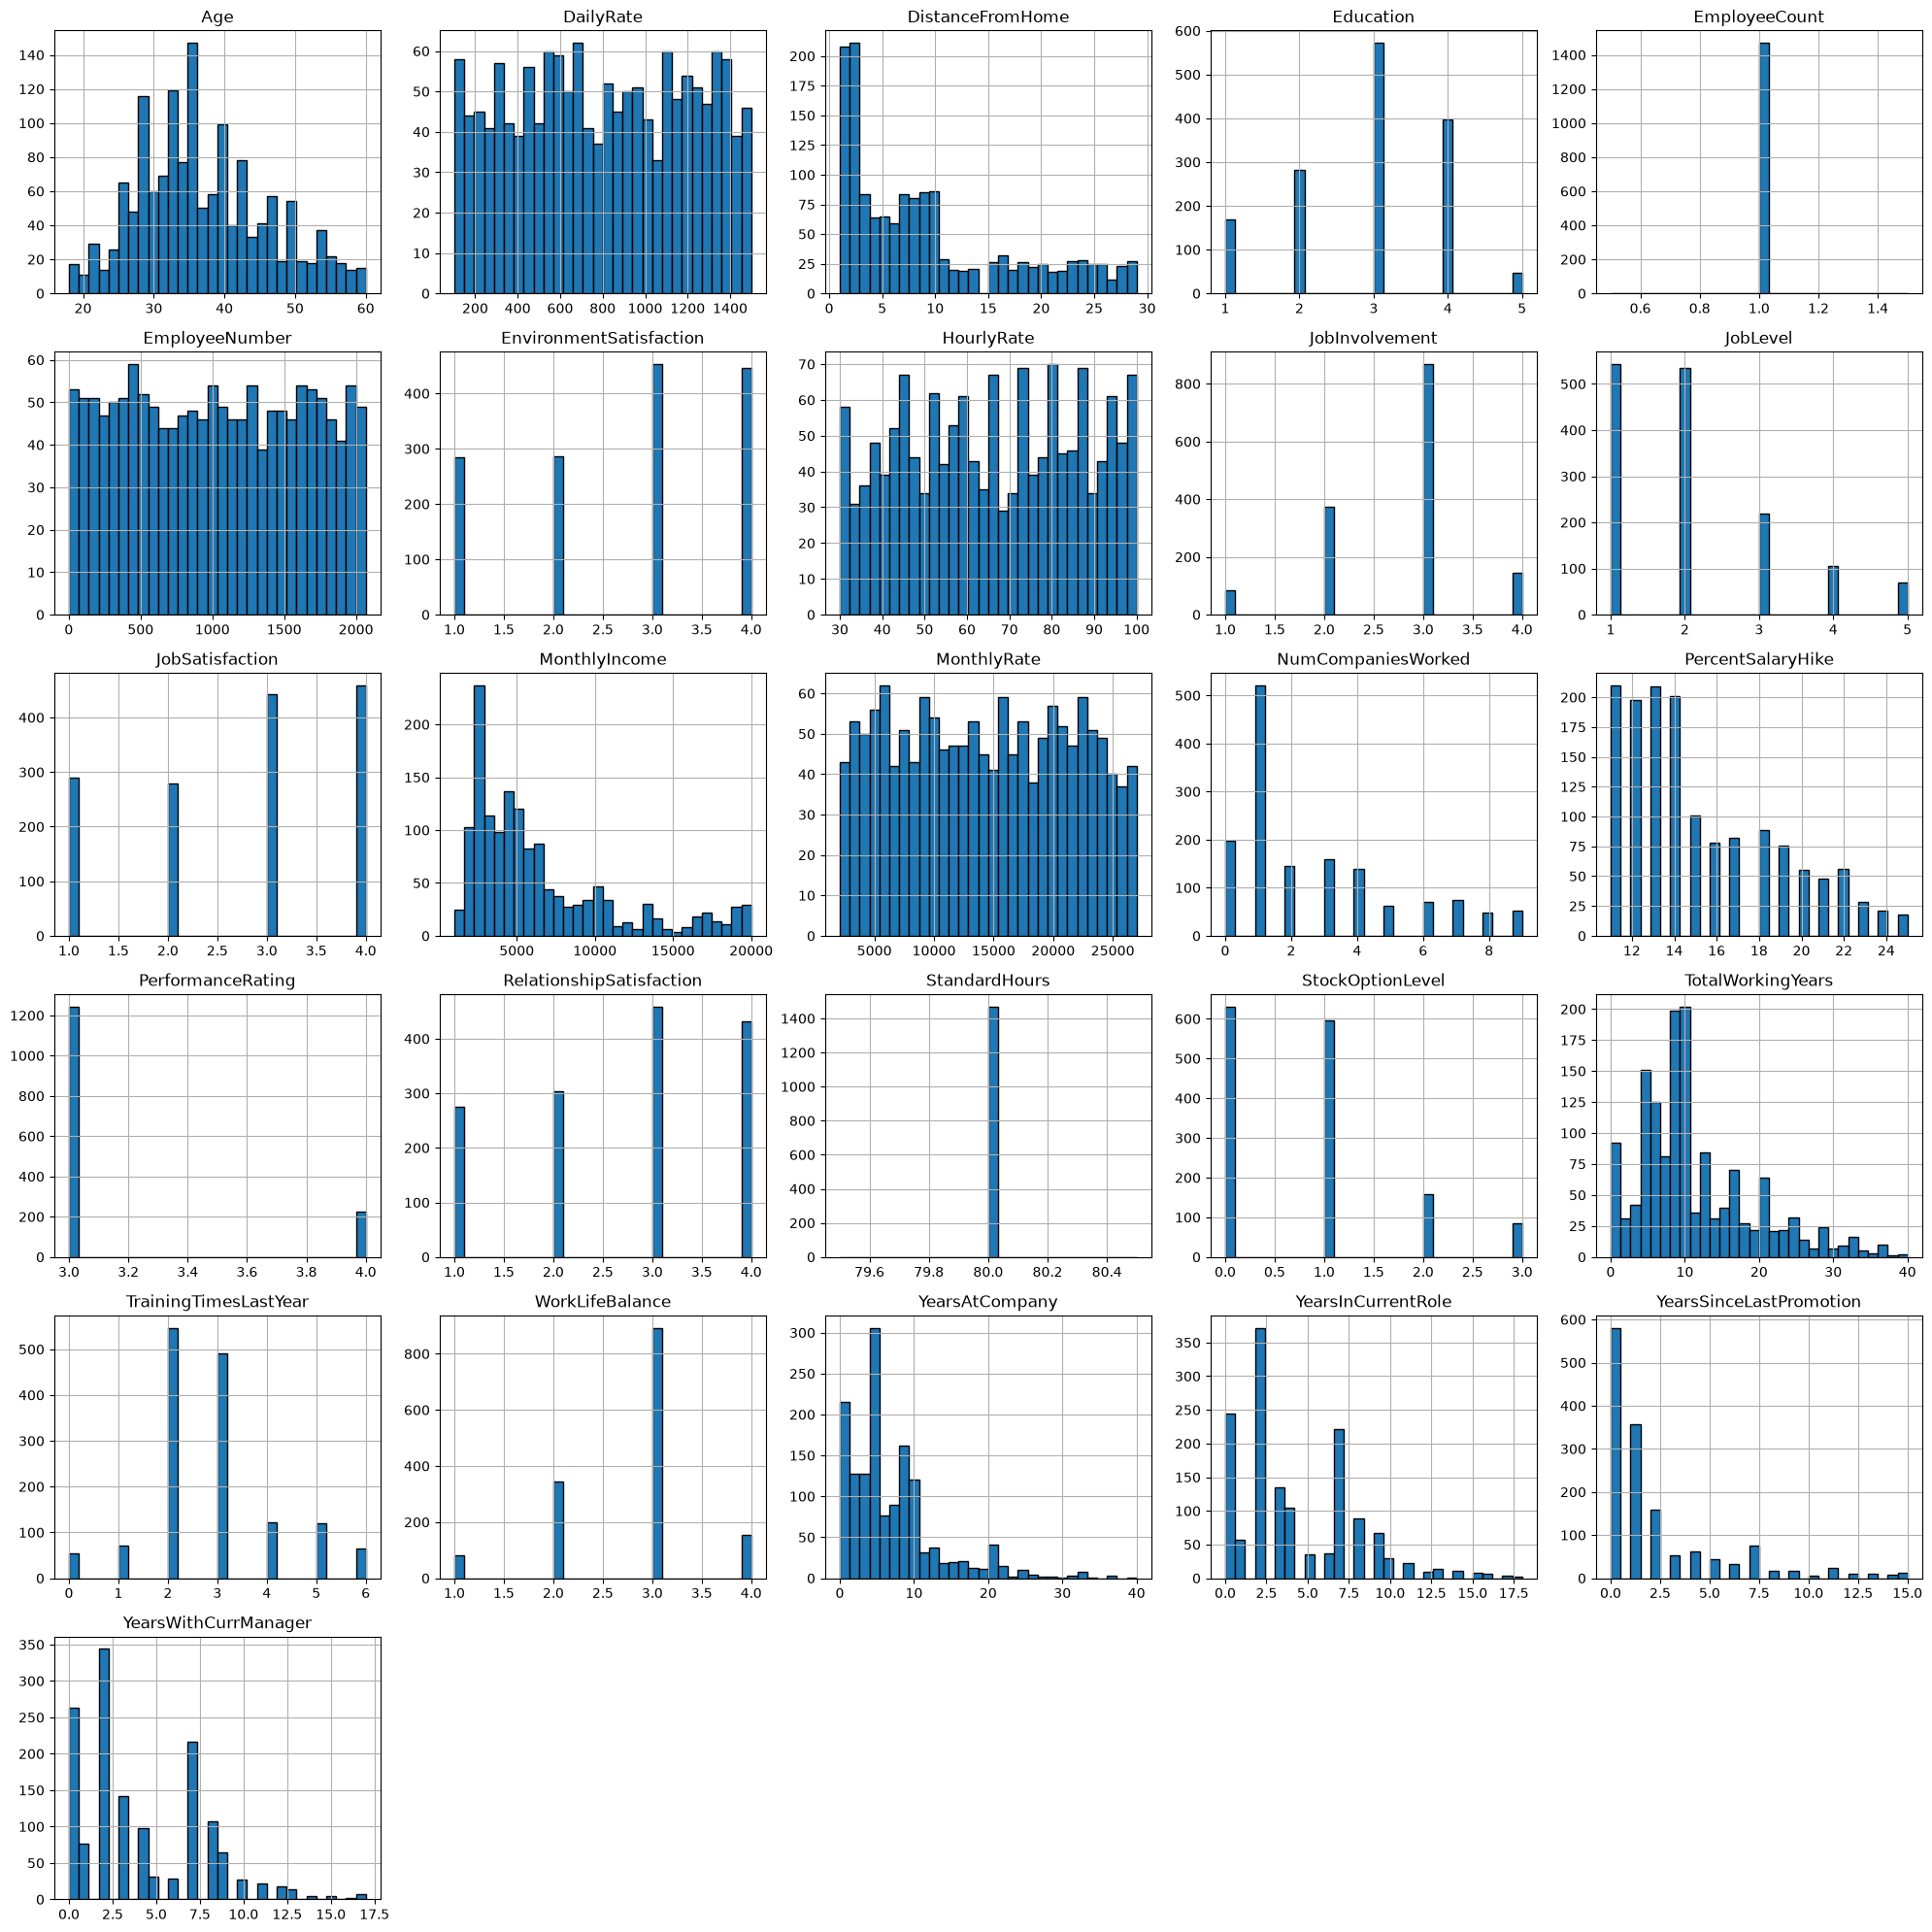

In [97]:
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()

print(numeric_cols)

df[numeric_cols].hist( edgecolor = "black", bins = 30, figsize=(20,20))
plt.tight_layout()
plt.show()

In [98]:
df.select_dtypes(include = {"category", "object"}).columns

C:\Users\shahh\AppData\Local\Temp\ipykernel_20876\3575370484.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include = {"category", "object"}).columns


Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'Over18', 'OverTime'],
      dtype='str')

___

C:\Users\shahh\AppData\Local\Temp\ipykernel_20876\2255764692.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()


['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


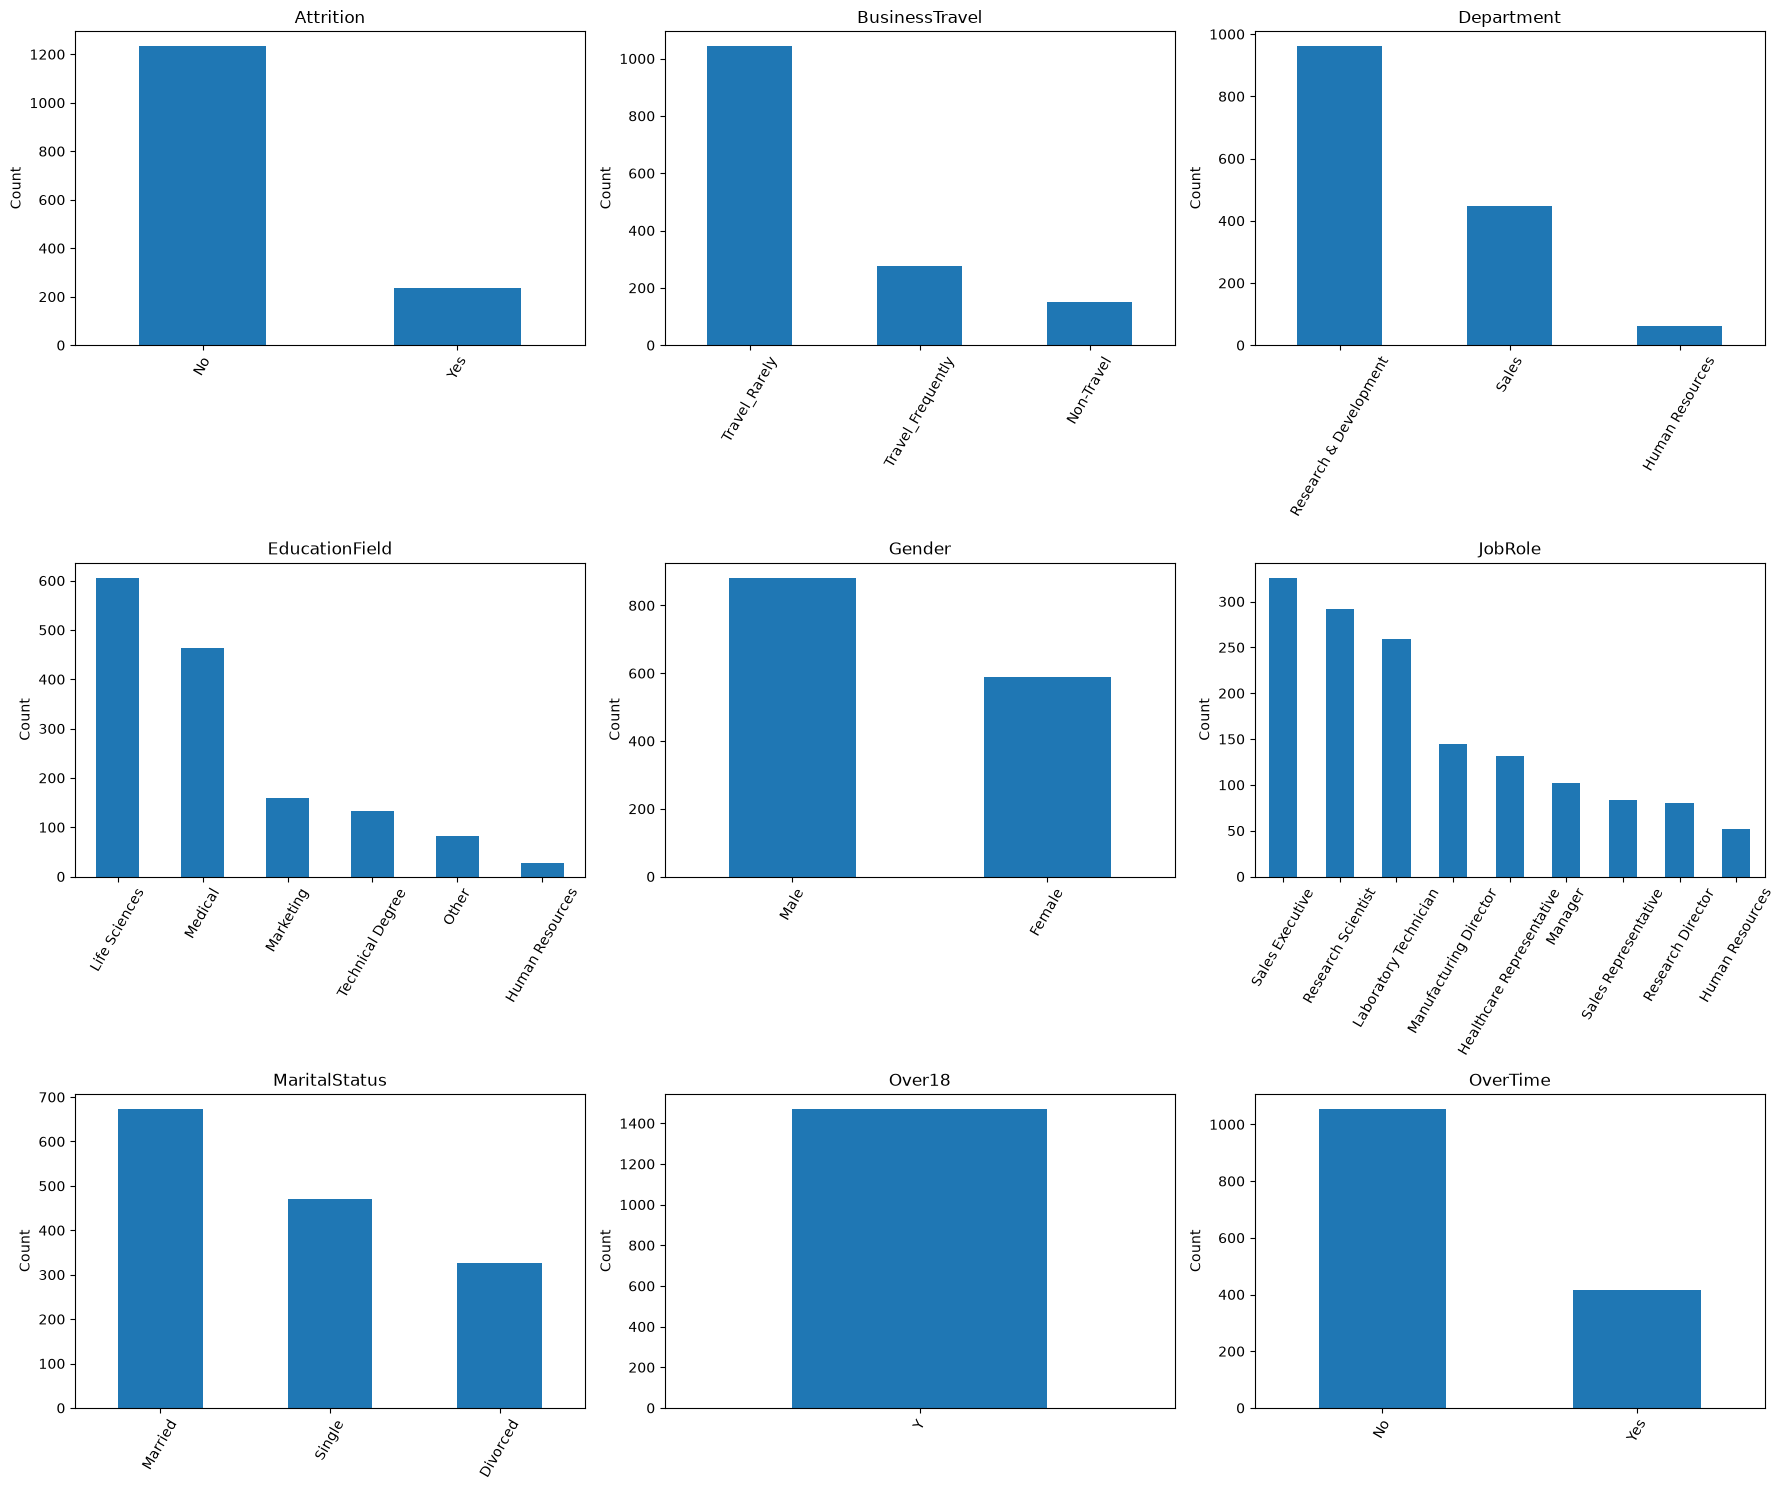

In [99]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print(categorical_cols)

fig, axes = plt.subplots(3, 3, figsize=(18, 15))

for col, ax in zip(categorical_cols, axes.flatten()):
    df[col].value_counts().plot(kind='bar', ax=ax)
    ax.set_title(col)
    ax.set_xlabel('')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=60)

plt.tight_layout()
plt.show()


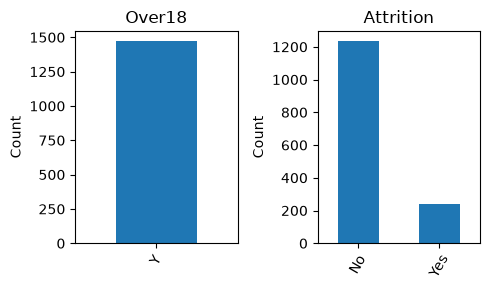

In [100]:
dropable_X_col = [ "Over18", "Attrition"]

fig, axes = plt.subplots(1, 2, figsize=(5, 3))

for col, ax in zip(dropable_X_col, axes.flatten()):
    df[col].value_counts().plot(kind='bar', ax=ax)
    ax.set_title(col)
    ax.set_xlabel('')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=60)

plt.tight_layout()
plt.show()

Over 18 is "yes" for all data thus removed from analysis.

In [101]:
num_df = df[numeric_cols]

<Axes: >

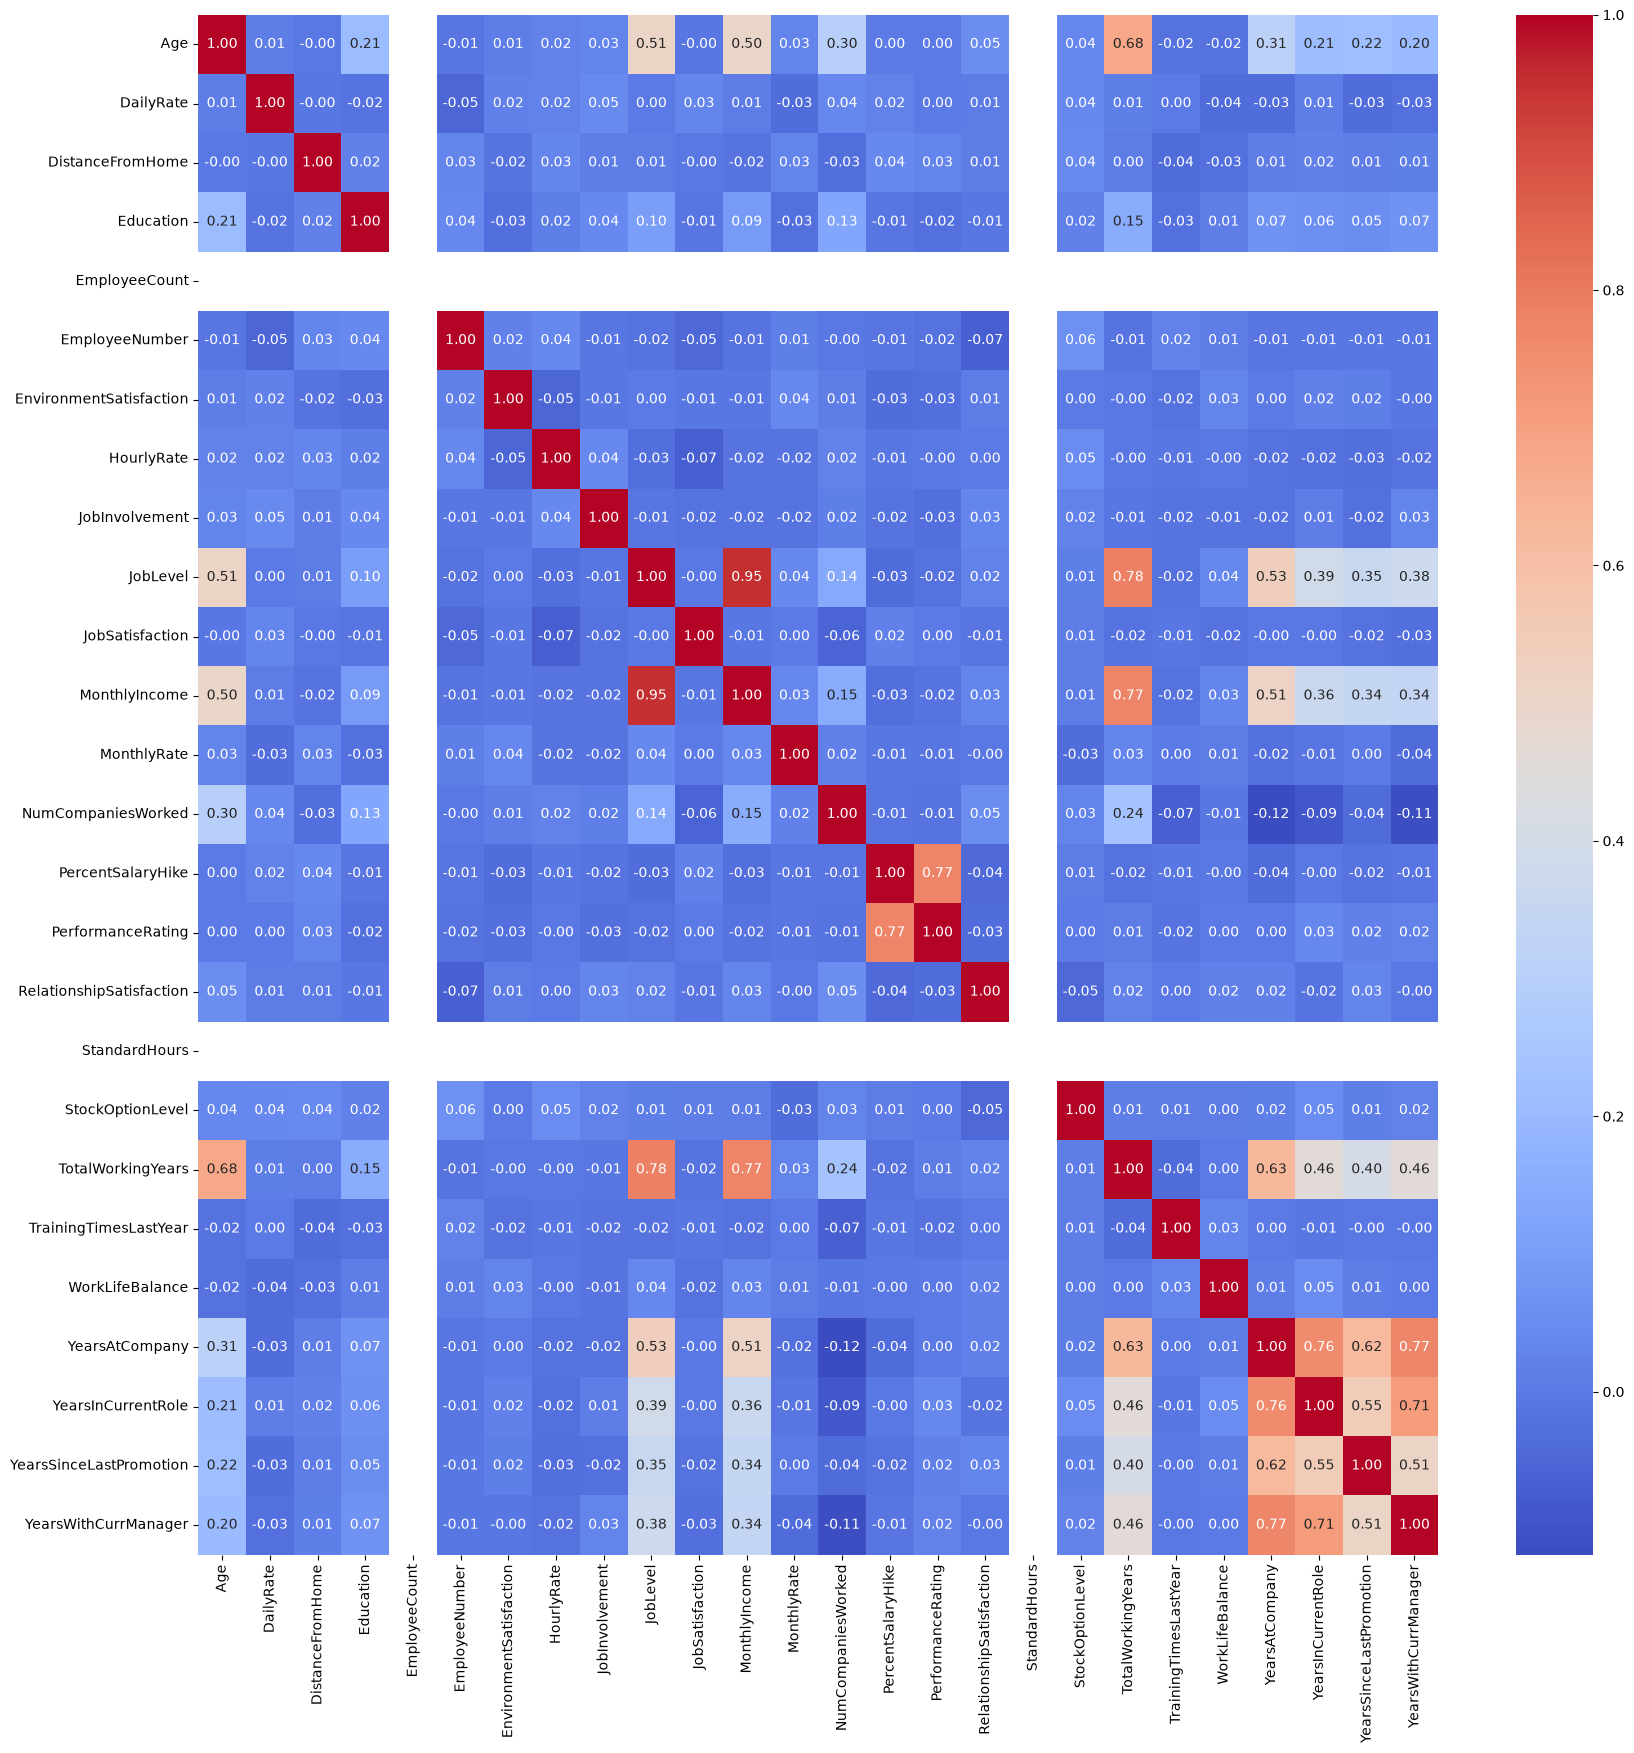

In [102]:
plt.figure(figsize = (20,20))
sns.heatmap(num_df.corr(numeric_only= True), annot = True ,fmt = ".2f" , cmap = "coolwarm")

This heatmap shows pairwise correlations between the variables. Red indicates a stronger positive correlation, while blue indicates a weak or near-zero correlation. The diagonal is 1.00 because each variable is perfectly correlated with itself.

Notable relationships include:

- **JobLevel and MonthlyIncome:** very strong positive correlation (**0.95**).
- **PercentSalaryHike and PerformanceRating:** strong positive correlation (**0.77**).
- **TotalWorkingYears** correlates with **Age (0.68)**, **YearsAtCompany (0.63)**, **MonthlyIncome (0.77)**, and **JobLevel (0.78)**.
- The tenure variables are positively related: **YearsAtCompany and YearsWithManager (0.77)**, **YearsAtCompany and YearsInCurrentRole (0.76)**, and **YearsInCurrentRole and YearsWithManager (0.71)**.
- Most other correlations are close to zero, suggesting weak linear relationships.

Correlation does not imply causation; also, the strong links among income, job level, and tenure may indicate overlapping information in a model.

___

Task 1 :
- Logistic regression is suitable for such case because the the predicted value comes with either yes or no , said the predicted values can be represented in binary 0 and 1.

Task 2:
- There are no missing values.

In [103]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split


# Task 3

In [104]:
X = df.drop('Attrition', axis=1)

X = X.drop(
    ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours'],
    axis=1
)

In [105]:
numeric_cols = X.select_dtypes(include=['number']).columns.tolist()

categorical_cols = X.select_dtypes(
    include=['object', 'category', 'string']
).columns.tolist()

print("Numeric columns:")
print(numeric_cols)

print("\nCategorical columns:")
print(categorical_cols)

Numeric columns:
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Categorical columns:
['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


In [106]:
y = df['Attrition'].map({
    'No': 0,
    'Yes': 1
})

In [107]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [108]:


preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(
            handle_unknown='ignore',
            drop='first'
        ), categorical_cols)
    ]
)
    

In [109]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

In [110]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Task 4

In [111]:
from sklearn.metrics import confusion_matrix, precision_score, f1_score, roc_auc_score, recall_score

In [112]:
confusion_matrix(y_test, y_pred)



array([[238,   9],
       [ 31,  16]])

In [113]:
precision_score(y_test, y_pred)

0.64

In [114]:
f1_score(y_test, y_pred)

0.4444444444444444

In [115]:
auc = roc_auc_score(y_test,y_pred)

auc

0.6519941424756655

# Task 5

In [116]:
# Get feature names after OneHotEncoder/StandardScaler
feature_names = model.named_steps["preprocessor"].get_feature_names_out()

# Get logistic regression coefficients
coefficients = model.named_steps["model"].coef_[0]

# Calculate odds ratios
odds_ratios = np.exp(coefficients)

# Create table
odds_ratio_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Odds_Ratio": odds_ratios
})

# Sort by odds ratio
odds_ratio_df.sort_values(
    "Odds_Ratio",
    ascending=False
)

,Feature,Coefficient,Odds_Ratio
43,cat__OverTime_Yes,1.796364,6.027692
23,cat__BusinessTravel_Travel_Frequently,1.549427,4.708772
34,cat__JobRole_Laboratory Technician,1.313674,3.719817
40,cat__JobRole_Sales Representative,0.957632,2.605518
42,cat__MaritalStatus_Single,0.684678,1.983133
24,cat__BusinessTravel_Travel_Rarely,0.679433,1.972759
33,cat__JobRole_Human Resources,0.528949,1.697148
21,num__YearsSinceLastPromotion,0.520141,1.682265
11,num__NumCompaniesWorked,0.480890,1.617514
2,num__DistanceFromHome,0.375241,1.455342


___

### Odds Ratio Interpretation

* **Odds Ratio (OR)** shows how a feature is associated with the odds of employee attrition.
* **OR > 1** → higher modeled odds of attrition.
* **OR < 1** → lower modeled odds of attrition.
* **Positive coefficient** → OR > 1, while **negative coefficient** → OR < 1.
* **OverTime = Yes** has a strong positive association with attrition (OR ≈ **2.72**).
* **Frequent business travel** is also associated with higher odds (OR ≈ **2.63**).
* **Years since last promotion** and some job roles show higher modeled odds.
* **Years in current role** and some satisfaction features are associated with lower odds.
* OR describes **odds, not a direct change in probability**.
* These results show **association, not causation**.


## 6. Class Imbalance

Class imbalance occurs when one class has more samples than another. In this dataset, **`No` (employees who stayed) is much more common than `Yes` (employees who left)**.

* The model may favor the majority class, **`No`**.
* In the confusion matrix, **28 attrition cases were predicted as `No`**, while **20 were correctly predicted as `Yes`**.
* Therefore, **accuracy alone is not sufficient**. Precision, recall, F1-score, and ROC-AUC should also be considered.

### Possible Solutions

* **Class Weighting:** Use `class_weight="balanced"` to give more importance to the minority class.
* **Oversampling:** Use methods such as **SMOTE** to increase minority-class samples.
* **Undersampling:** Reduce samples from the majority class.
* **Threshold Adjustment:** Change the prediction threshold to improve recall for attrition cases.

Handling class imbalance can help the model identify more employees who may leave the company.


___
___